In [172]:
from pathlib import Path

import pickle
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set(
    style="white",
    rc={
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
    },
    font="BIZ UDGothic"
)
import matplotlib_fontja

In [51]:
image_path = Path("images")

In [59]:
df = pd.read_csv("data/20251101coolrevolution実績.csv", parse_dates=["受注_伝票登録日付"])
df = df.rename(columns={"受注_伝票登録日付": "date", "売上金額": "sales"})
df["day"] = df.date.dt.date
sales = df.groupby(pd.Grouper(key='date', freq='MS'))["請求済数量"].sum()
inventory_cap = pd.read_csv("data/クーレボ在庫.csv")
inventory_cap.yyyymm = inventory_cap.yyyymm.map(lambda x: pd.to_datetime(str(x)+"01"))
inventory_cap = inventory_cap.rename(columns={"yyyymm": "date", '在庫数（月末時点）': 'inventory'})
inventory_cap = inventory_cap.set_index('date')["inventory"]

data = pd.DataFrame({"sales": sales, "inventory": inventory_cap}).dropna(axis=0, how='any')
# data = data.reindex(index=pd.date_range("2019-10-01", '2025-06-01', freq='MS'))
data['month'] = data.index.month

# 在庫キャップ
data['inventory_cap'] = data[['inventory', 'sales']].max(axis=1)
data = data.fillna(0)
data = data.reset_index()
data = data.set_index("date")

In [115]:
data[data['inventory_cap']==0]

,sales,inventory,month,inventory_cap
date,,,,
2024-12-01,0.0,0,12,0.0
2025-01-01,0.0,0,1,0.0
2025-02-01,0.0,0,2,0.0


## 分析結果

In [62]:
with open("results/normal/posterior.pickle", mode='rb') as f:
    posterior = pickle.load(f)

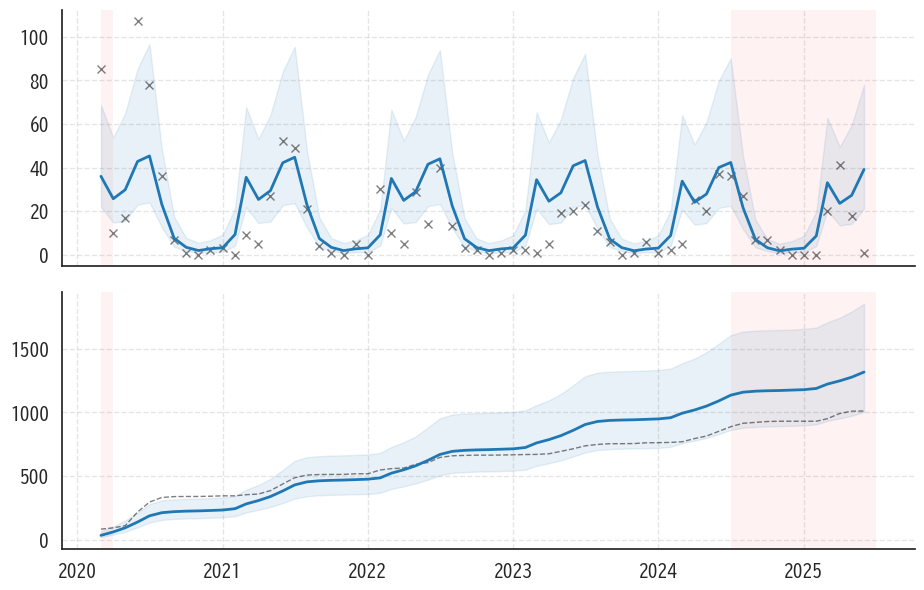

In [173]:
demand_pred = pd.DataFrame(posterior['demand_pred']).T
demand_pred.index = data.index


m = demand_pred.median(axis=1)
u = demand_pred.quantile(0.975, axis=1)
l = demand_pred.quantile(0.025, axis=1)

cm = demand_pred.cumsum(axis=0).median(axis=1)
cu = demand_pred.cumsum(axis=0).quantile(0.975, axis=1)
cl = demand_pred.cumsum(axis=0).quantile(0.025, axis=1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw={'hspace': 0.1})

stockout_indices = data.index[(data["inventory"] - data["sales"]) <= 10]
for ax in [ax1, ax2]:
    first_label = True
    for date in stockout_indices:
        # 条件に合う月を赤色でハイライト（alphaを薄くして視認性を確保）
        ax.axvspan(date, date + pd.DateOffset(months=1), color='red', alpha=0.05, 
                   label='在庫完売（供給制限）' if first_label else None, lw=0)
        first_label = False    

    
# --- 上段：月次販売台数 ---
ax1.plot(sales.index, sales, color='black', label='販売台数', marker='x', alpha=0.5, linewidth=0.0,)
ax1.plot(m.index, m, color='#1f77b4', lw=2, label='潜在需要の中央値')
ax1.fill_between(m.index, l, u, color='#1f77b4', alpha=0.10, label='潜在需要の95%信頼区間')
ax1.set_ylabel("", fontsize=12, fontweight='bold')

ax2.plot(sales.index, sales.cumsum(), color='black', label='累積販売台数', alpha=0.5, linewidth=1.0, linestyle='--')
ax2.plot(cm.index, cm, color='#1f77b4', lw=2, label='潜在需要の累積の中央値')
ax2.fill_between(cm.index, cl, cu, color='#1f77b4', alpha=0.10, label='潜在需要の累積の95%信頼区間')
ax2.set_ylabel("", fontsize=12, fontweight='bold')


# 共通の装飾
for ax in [ax1, ax2]:
    ax.grid(True, which='major', linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


plt.savefig("images/in_sample_time_series.pdf", format='pdf', transparent=True)

In [218]:
## P, Qに関する分布

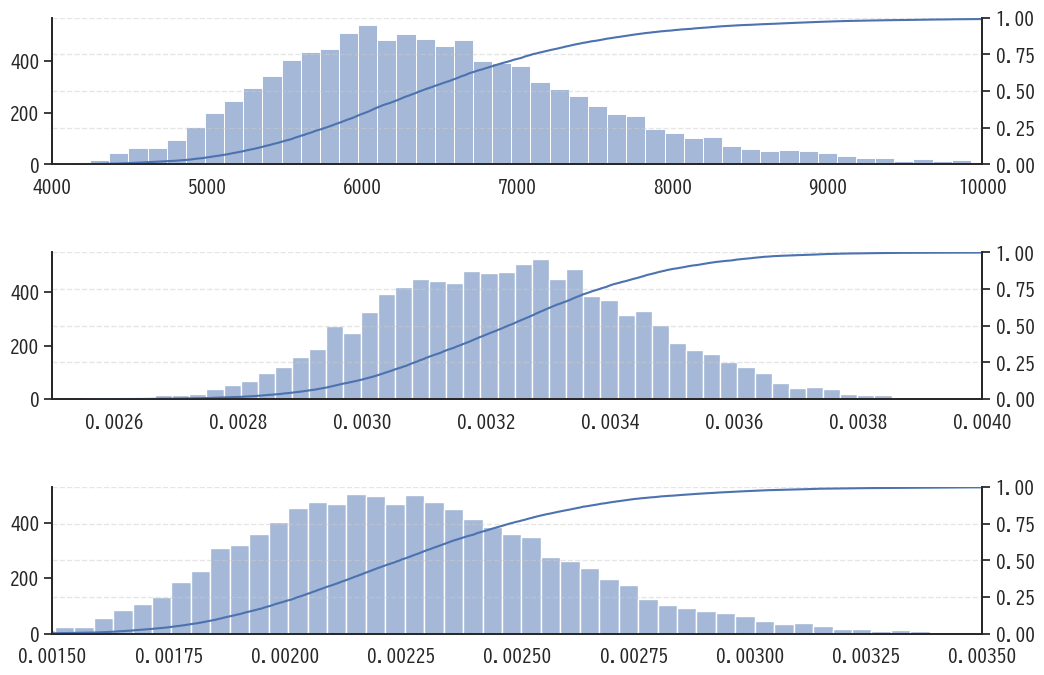

In [276]:
M = pd.Series(posterior["M"])
p = np.exp(pd.Series(posterior["log_p"]))
q = np.exp(pd.Series(posterior["log_q"]))

acc_M = M.value_counts().sort_index().cumsum() / len(M)
acc_p = p.value_counts().sort_index().cumsum() / len(p)
acc_q = q.value_counts().sort_index().cumsum() / len(q)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), gridspec_kw={'hspace': 0.6})
sns.histplot(posterior["M"], ax=ax1, alpha=0.5)
ax1_ = ax1.twinx()
sns.lineplot(acc_M, ax=ax1_)
ax1.set_xlim([4000, 10000])
ax1_.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax1_.set_ylabel("")
ax1_.set_ylim([0, 1])
ax1_.grid()
ax1.set_ylabel("")

ax2_ = ax2.twinx()
sns.histplot(p, ax=ax2, alpha=0.5)
sns.lineplot(acc_p, ax=ax2_);
ax2.set_ylabel("")
ax2_.set_ylabel("")
ax2_.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax2_.set_ylim([0, 1])
ax2.set_xlim([0.0025, 0.004])

ax3_ = ax3.twinx()
sns.histplot(q, ax=ax3, alpha=0.5)
sns.lineplot(acc_q, ax=ax3_);
ax3.set_ylabel("")
ax3_.set_ylabel("")
ax3_.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax3_.set_ylim([0, 1])
ax3.set_xlim([0.0015, 0.0035])

for ax in [ax1_, ax2_, ax3_]:
    ax.grid(True, which='major', linestyle='--', alpha=0.5)

for ax in [ax1, ax1_, ax2, ax2_, ax3, ax3_]:
    ax.spines['top'].set_visible(False)

filename = "p_q_M.pdf"
file_path = image_path / filename
plt.savefig(file_path, format="pdf", transparent=True)

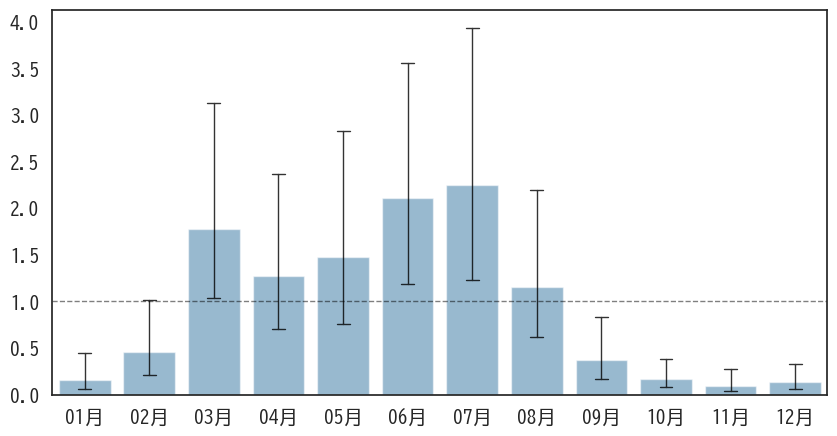

In [274]:
season_factor = pd.DataFrame(posterior['season_factors']).T
season_factor.index = [f"{d:02d}月" for d in range(1, 13)]
# sns.barplot(season_factor.T)

df_melted = season_factor.reset_index().melt(id_vars='index', var_name='sample', value_name='factor')
df_melted.columns = ['month', 'sample', 'factor']

fig, ax = plt.subplots(1, figsize=(10, 5))
# pointplotは自動的に平均（または中央値）と信頼区間を計算して描画します
sns.barplot(
    data=df_melted, 
    x='month', 
    y='factor', 
    estimator='median',     # 中央値をバーの高さに
    errorbar=('pi', 95),    # 95%信頼区間
    capsize=0.2,            # ★ここでヒゲの先端に横棒を追加（幅を指定）
    color='#1f77b4', 
    alpha=0.5,
    err_kws={
        'color': 'black',  # エラーバーの色（例：鮮やかな赤）
        'linewidth': 1.0,    # エラーバーの太さ
        'alpha': 0.8,         # エラーバーの透明度
        'linestyle': '-'
    },
    ax=ax
)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.5)
_ = ax.set_ylabel("")
_ = ax.set_xlabel("")

filename = "seasonality.pdf"
file_path = image_path / filename
plt.savefig(file_path, format="pdf", transparent=True)

# 予測

In [223]:
demand_pred = pd.read_csv("results/normal/demand_pred.csv", parse_dates=["dates"]).set_index("dates")
m = demand_pred["2026-03":].median(axis=1)
upper = demand_pred["2026-03":].quantile(0.975, axis=1)
lower = demand_pred["2026-03":].quantile(0.025, axis=1)

cumsum_m = demand_pred["2026-03":].cumsum(axis=0).median(axis=1)
cumsum_upper = demand_pred["2026-03":].cumsum(axis=0).quantile(0.975, axis=1)
cumsum_lower = demand_pred["2026-03":].cumsum(axis=0).quantile(0.025, axis=1)

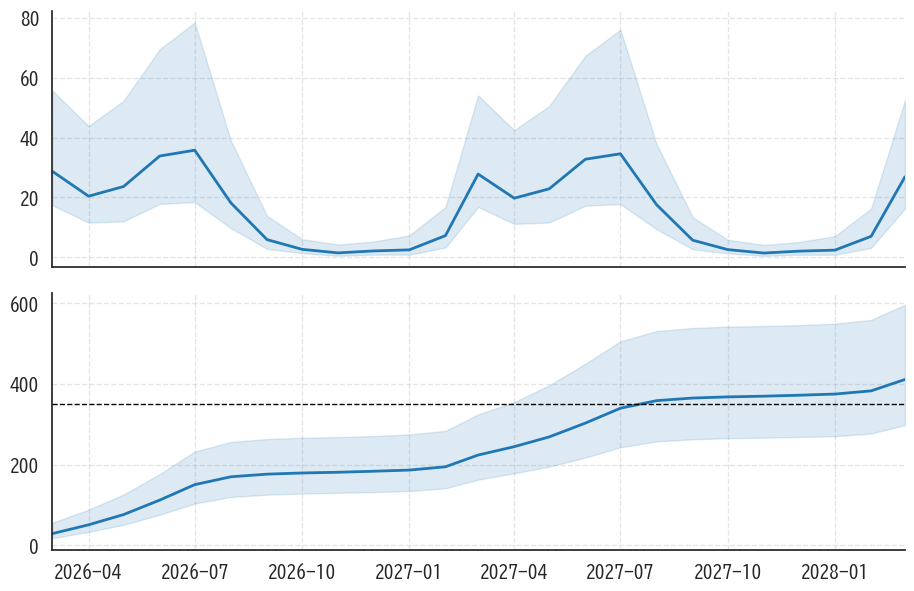

In [230]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw={'hspace': 0.1})
    
# --- 上段：月次販売台数 ---
ax1.plot(m.index, m, color='#1f77b4', lw=2, label='中央値')
ax1.fill_between(m.index, lower, upper, color='#1f77b4', alpha=0.15, label='95%信頼区間')
ax1.set_ylabel("", fontsize=12, fontweight='bold')
# ax1.set_title("需要予測および累積予測シミュレーション (2026-03以降)", loc='left', fontsize=12, pad=15)

# --- 下段：累積販売台数 ---
ax2.plot(cumsum_m.index, cumsum_m, color='#1f77b4', lw=2, label='中央値')
ax2.fill_between(cumsum_m.index, cumsum_lower, cumsum_upper, color='#1f77b4', alpha=0.15, label='95%信頼区間')
ax2.axhline(350, linestyle='--', linewidth=1, color='black')
ax2.set_ylabel("", fontsize=12, fontweight='bold')
ax2.set_xlim([cumsum_m.index[0], cumsum_m.index[-1]])

# 共通の装飾
for ax in [ax1, ax2]:
    ax.grid(True, which='major', linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

filename = "future_demand_prediction.pdf"
file_path = image_path / filename
plt.savefig(file_path, format="pdf", transparent=True)